# Modifying ABCMB

In this script we demonstrate how to efficiently implement a new physics fluid species to the cosmological model.

TODO: Discuss how to add new species, how to handle delta_idx? Not by the user?

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

from classy import Class
from ABCMB.main import Model
from ABCMB.species import Fluid, StandardFluid, BackgroundFluid
import ABCMB.constants as cnst
from ABCMB import species, spectrum

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import equinox as eqx

ERROR:2025-11-26 13:07:45,198:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/ext3/miniconda3/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 197, in _version_check
    version = get_version()
RuntimeError: jaxlib/cuda/versions_helpers.cc:34: operation cudaRuntimeGetVersion(&version) failed: Error loading CUDA libraries. GPU will not be used.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zz1994/.local/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/ext3/miniconda3/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/ext3/miniconda3/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 229

## Example: $w_0w_a$ (Dynamical Dark Energy)

The user might also wish to implement a species without any inhomogeneity. Such a species would only contribute to the background portion of the Friedmann equation, i.e. modify Hubble in an interesting way. 

One such model, the dynamical dark energy, has gained much attention in light of the recent DESI data. We demonstrate here how to implement such a model, and similar models that do not require a perturbation Boltzmann hierarchy. 

Since the model has no perturbations, it is no longer necessary to implement the functions y_ini() and y_prime(). This means the class w0wa should not inherit from AbstractPerturbedFluid, which requires that all children implement these functions. Instead, we will go one step up the chain and inherit from the perturbations-free parent class, AbstractFluid.

In [24]:
class DynamicalDarkEnergy(BackgroundFluid, strict=True):

    name = "DynamicalDarkEnergy"
    
    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)

    def rho(self, lna, params):
        """
        Energy density at log scale factor lna.
        Should be in units of eV/cm^3.

        Parameterized as the redshift behavior based on its energy density today.
        rho = rho0 x a^{-3(1+w)}
        """
        # Energy density today
        rho0 = params["omega_Lambda"] * (3.*cnst.H0_over_h**2/8./jnp.pi/cnst.G)
        a = jnp.exp(lna)
        w = params["w0DE"] + (1-a)*params["waDE"]
        
        return rho0 * a**(-3.*(1.+w))

    def P(self, lna, params):
        """
        Pressure at log scale factor lna.
        """
        a = jnp.exp(lna)
        w = params["w0DE"] + (1-a)*params["waDE"]
        return w*self.rho(lna, params)

    def cs2(self, lna, params):
        """
        Sound speed squared.
        This is not used, but for good programming structure it must be instantiated.
        Set to some trivial value. 
        """
        return 0.

In [18]:
3*(11/4)**(4/3) * 0.71611**4

3.039604882450522

## Example: SIDR

We will first look at the strongly self-interacting dark radiation model. This scenario can be realised by a secluded dark sector of massless particles, whose self-interaction remains effective throughout cosmological history $\left(\frac{\Gamma}{H}\gg 1\right)$. Such interaction reduces the full Boltzmann hierarchy required for a free-streaming species down to the $\ell=0, 1$ modes.

Here, the user can define a new SIDR class, which inherits from ABCMB's template class, StandardFluid.

In [3]:
class SIDR(StandardFluid):

    name = "SelfInteractingDarkRadiation"
    
    # Number of modes in the Boltzmann Hierarchy
    num_ell_modes = 2 # Non free-streaming species only require density and velocity perturbations

    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)
    
    def rho(self, lna, params):
        """
        Energy density at log scale factor lna.
        Should be in units of eV/cm^3.

        Here the energy density is parameterized in terms of the number of extra SM neutrino species:
        
        rho1nu = 7/8 x (4/11)^(4/3) x rhoCMB

        where rhoCMB = pi^2/15 TCMB0^4 / a^4,

        and rho_idr = N_idr x rho1nu
        """
        a = jnp.exp(lna)

        # Note: params['TCMB0'] is in eV, so we need three factors of 1/(hbar c) to convert to eV/cm^3
        rho1nu = 7./8. * (4./11.)**(4./3.) * jnp.pi**2 / 15. * params['TCMB0']**4 / a**4 / (cnst.hbar*cnst.c)**3
        return params["N_idr"] * rho1nu

    def P(self, lna, params):
        """
        Pressure at log scale factor lna.
        For fully relativistic species this is simply rho/3.
        """
        return self.rho(lna, params)/3.

    def cs2(self, lna, params):
        """
        Sound speed squared.
        For fully relativistic perfect fluid cs2 = 1/3.
        """
        return 1./3.

    def y_ini(self, k, tau_ini, om, args):
        """
        Adiabatic superhorizon initial conditions for SIDR.
        For all relativistic species they are matched to neutrinos.
        """
        params = args
        R_nu = params['R_nu']

        delta = - (k*tau_ini)**2/3. * (1.-om*tau_ini/5.)
        theta = - k*(k*tau_ini)**3/36./(4.*R_nu+15.) \
                * (4.*R_nu+11.+12.-3.*(8.*R_nu**2+50.*R_nu+275.)/20./(2.*R_nu+15.)*tau_ini*om)
        return jnp.array([delta, theta])

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        """
        Derivatives of the SIDR perturbations w.r.t. lna.
        """
        BG, params, _, _ = args
        aH = BG.aH(lna, params)

        # First find the delta and theta that belong to SIDR
        delta = y[self.delta_idx]
        theta = y[self.delta_idx+1]
        
        delta_prime = -4./3./aH*theta - 2./3.*metric_h_prime
        theta_prime = k**2/aH*delta/4.

        return jnp.array([delta_prime, theta_prime])

In [4]:
lmax = 2500
specs = {
    "output_Cl" : True,
    "l_max" : lmax,
    "lensing" : False,
    "output_Pk" : False,
    "l_max_g" : 12,
    "l_max_pol_g" : 10,
    "l_max_ur" : 17
}
user_species = (SIDR,)

In [5]:
SIDRmodel = Model(specs, user_species, return_PTBG=True)

In [6]:
params = {
    'h': 0.6762,
    'omega_cdm': 0.1193,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'Neff': 3.044,
    'YHe': 0.245,
    'TCMB0': 2.34865418e-4,
    'T_nu': (4./11.)**(1./3.),
    'N_idr' : jnp.array(.1),
}

In [7]:
data, label = SIDRmodel.run_cosmology(params)

In [8]:
params = SIDRmodel.add_derived_parameters(params)

In [17]:
class_params = {
    "output": "mPk, tCl, pCl, lCl" if specs["lensing"] else "mPk, tCl, pCl",
    "l_max_scalars" : lmax,
    "k_output_values" : "0.001, 0.01, 0.1, 0.4",
    "lensing" : "yes" if specs["lensing"] else "no",
    "H0": params["h"]*100,
    "omega_b": params["omega_b"],
    "omega_cdm": params["omega_cdm"],
    "A_s" : params["A_s"],
    "n_s" : params["n_s"],
    "N_ur": params["N_ur"],
    "YHe": params["YHe"],
    "N_ncdm": params["N_ncdm"],
    "N_idr" : params["N_idr"],
    "idr_nature" : "fluid",
    #"reio_parametrization" : "reio_none",
    "reio_parametrization" : "reio_camb",
    "z_reio" : 11,
    "reionization_width" : 0.5,
    "helium_fullreio_redshift" : 3.5,
    "helium_fullreio_width" : 0.5,
    "reionization_exponent" : 1.5,
    "l_max_g": specs["l_max_g"],
    "l_max_pol_g": specs["l_max_pol_g"],
    "l_max_ur": specs["l_max_ur"], 
    "radiation_streaming_trigger_tau_over_tau_k" : 20000,
    "radiation_streaming_trigger_tau_c_over_tau" : 2000,
    "ur_fluid_trigger_tau_over_tau_k" : 10000, 
    "ncdm_fluid_trigger_tau_over_tau_k" : 15000} 
class_lcdm = Class()
class_lcdm.set(class_params)
if params["N_ncdm"] > 0:
    class_lcdm.set({"m_ncdm": params["m_ncdm"], "T_ncdm": params["T_ncdm"]})
class_lcdm.compute()

### Checking Background

In [10]:
class_bg = class_lcdm.get_background()
BG = label[-1]

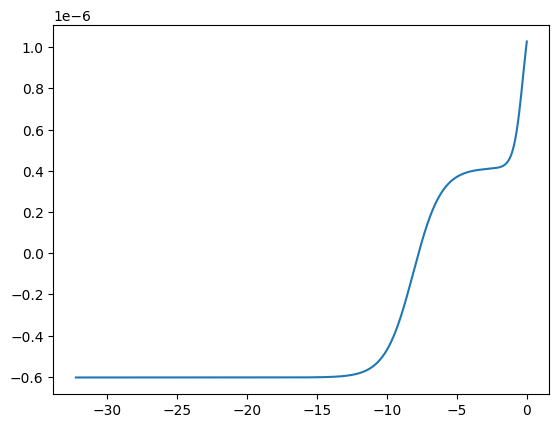

In [11]:
a = 1./(class_bg["z"]+1)
lna = jnp.log(a)
class_aH = a*class_bg['H [1/Mpc]']
abcmb_aH = BG.aH(lna, params)

#plt.plot(lna, class_aH)
#plt.plot(lna, abcmb_aH, "--")
#plt.yscale("log")
plt.plot(lna, abcmb_aH/class_aH - 1.)
plt.show()

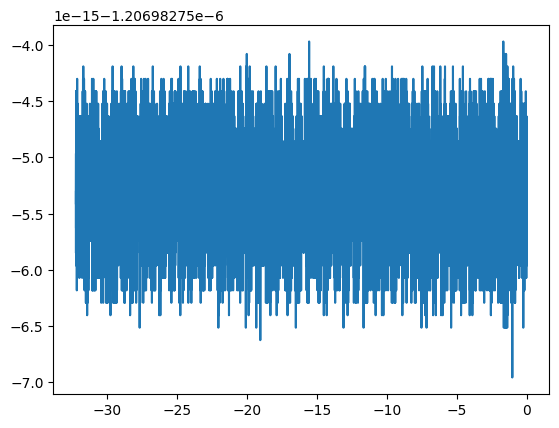

In [12]:
class_idr = class_bg['(.)rho_idr'] * 3/8./jnp.pi/cnst.G * cnst.c_Mpc_over_s**2
abcmb_idr = SIDRmodel.species_list[-1].rho(lna, params)
#plt.plot(lna, class_idr)
#plt.plot(lna, SIDRmodel.species_list[-1].rho(lna, params), "--")
#plt.yscale("log")
plt.plot(lna, abcmb_idr/class_idr - 1.)
plt.show()

### Checking Cls

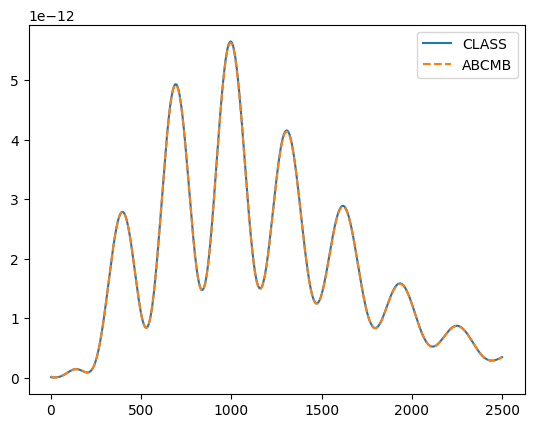

In [18]:
ell = label[0]
abcmb_tt = data[0] * ell*(ell+1)/2./jnp.pi
abcmb_te = data[1] * ell*(ell+1)/2./jnp.pi
abcmb_ee = data[2] * ell*(ell+1)/2./jnp.pi

class_ell = class_lcdm.raw_cl(lmax)["ell"]
class_tt = class_lcdm.raw_cl(lmax)["tt"] * class_ell*(class_ell+1)/2./jnp.pi
class_ee = class_lcdm.raw_cl(lmax)["ee"] * class_ell*(class_ell+1)/2./jnp.pi

plt.plot(class_ell[ell],  class_ee[ell], label='CLASS')
plt.plot(ell, abcmb_ee, "--", label='ABCMB')
plt.legend()
plt.show()

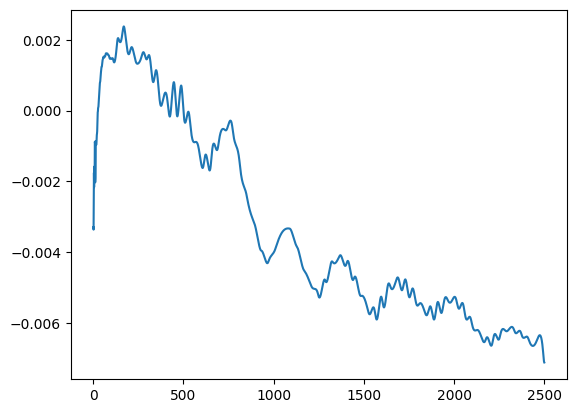

In [20]:
plt.plot(ell, abcmb_tt/class_tt[ell] - 1.)

## Example: Interacting DM-DR

For the last example we demonstrate how one could implement interacting species in ABCMB. 

In [26]:
class IDM(species.ColdDarkMatter):

    num_ell_modes = 2 # Interacting DM will have velocity perturbation.
    name = "InteractingDarkMatter"

    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)

    def y_ini(self, k, tau_ini, om, args):
        """
        Adiabatic initial conditions.
        For non-relativistic species we match to CDM and baryons for density, and baryons for velocity
        """
        params = args
        delta = -(k*tau_ini)**2/4. * (1.-om*tau_ini/5.)
        theta = - k**4 * tau_ini**3/36. * (1.-3.*(1.+5.*params['R_b']-params['R_nu'])/20./(1.-params['R_nu'])*om*tau_ini)
        return jnp.array([delta, theta])

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        BG, params, species_list, species_dict = args
        
        # Get IDR from list
        i = species_dict["InteractingDarkRadiation"]
        IDR = species_list[i]

        a = jnp.exp(lna)
        aH = BG.aH(lna, params)

        delta = y[self.delta_idx]
        theta = y[self.delta_idx+1]
        theta_idr = y[IDR.delta_idx+1]
        
        delta_prime = -theta/aH-metric_h_prime/2.
        theta_prime = -theta + params["Gamma0dmdr"]/a/aH * (theta_idr - theta)
        
        return jnp.array([delta_prime, theta_prime])

class IDR(SIDR):

    name = "InteractingDarkRadiation"

    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        """
        Derivatives of the SIDR perturbations w.r.t. lna.
        """
        BG, params, species_list, species_dict = args
        
        # Get IDM from list
        i = species_dict["InteractingDarkMatter"]
        IDM = species_list[i]

        a = jnp.exp(lna)
        aH = BG.aH(lna, params)
        R = 3. * IDM.rho(lna, params) / 4. / self.rho(lna, params)

        # First find the delta and theta that belong to SIDR
        delta = y[self.delta_idx]
        theta = y[self.delta_idx+1]
        theta_idm = y[IDM.delta_idx+1]
        
        delta_prime = -4./3./aH*theta - 2./3.*metric_h_prime
        theta_prime = k**2/aH*delta/4. + R * params["Gamma0dmdr"]/a/aH * (theta_idm - theta)

        return jnp.array([delta_prime, theta_prime])

In [34]:
lmax = 2500
specs = {
    "use_LCDM_species" : False,
    "output_Cl" : True,
    "l_max" : lmax,
    "lensing" : False,
    "output_Pk" : True,
    "output_k_max" : 0.5,
    "l_max_g" : 12,
    "l_max_pol_g" : 10,
    "l_max_ur" : 17
}
user_species = (species.DarkEnergy, IDM, IDR, species.Baryon, species.Photon, species.MasslessNeutrino)

In [35]:
IDRDMmodel = Model(specs, user_species, return_PTBG=True)

In [36]:
IDRDMmodel.species_dict

{'DarkEnergy': 0,
 'InteractingDarkMatter': 1,
 'InteractingDarkRadiation': 2,
 'Baryon': 3,
 'Photon': 4,
 'MasslessNeutrino': 5}

In [37]:
params = {
    'h': 0.6762,
    'omega_cdm': 0.1193,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'Neff': 3.044,
    'YHe': 0.245,
    'TCMB0': 2.34865418e-4,
    'T_nu': (4./11.)**(1./3.),
    'N_idr' : jnp.array(.1),
    'Gamma0dmdr' : jnp.array(4.e-7),
}

In [39]:
data, label = IDRDMmodel.run_cosmology(params)

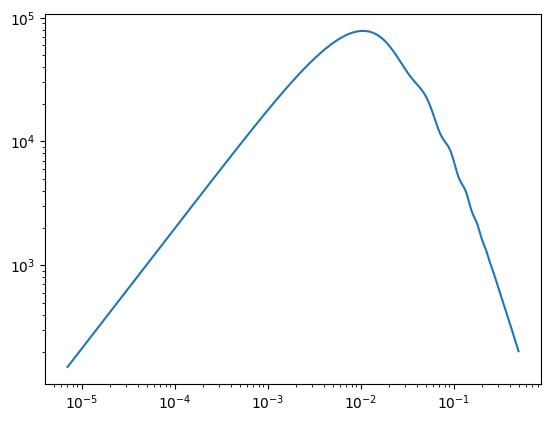

In [41]:
plt.loglog(label[1], data[-1])
plt.show()

In [43]:
lmax = 2500
specs = {
    "output_Cl" : True,
    "l_max" : lmax,
    "lensing" : False,
    "output_Pk" : True,
    "output_k_max" : 0.5,
    "l_max_g" : 12,
    "l_max_pol_g" : 10,
    "l_max_ur" : 17
}
LCDM = Model(specs, None, return_PTBG=True)

In [45]:
LCDMdata, LCDMlabel = LCDM.run_cosmology(params)

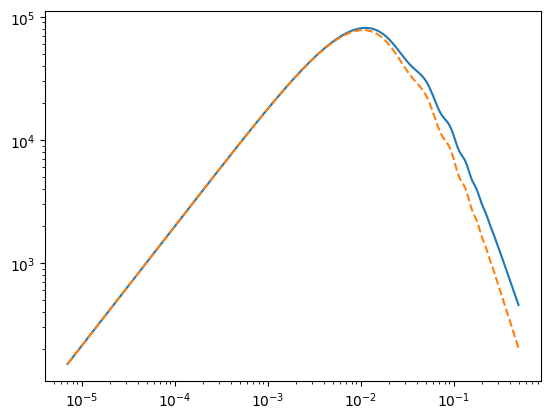

In [46]:
plt.loglog(LCDMlabel[1], LCDMdata[-1])
plt.loglog(label[1], data[-1], "--")
plt.show()

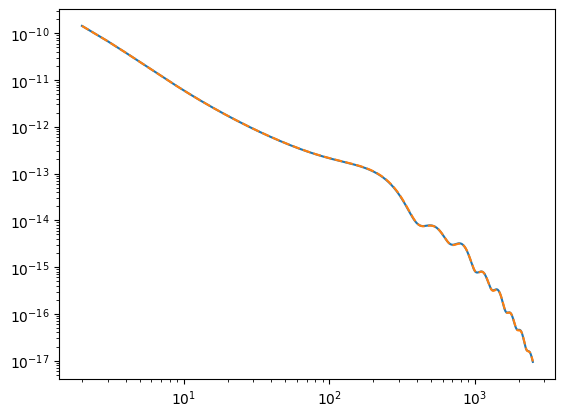

In [47]:
plt.loglog(LCDMlabel[0], LCDMdata[0])
plt.loglog(label[0], data[0], "--")
plt.show()

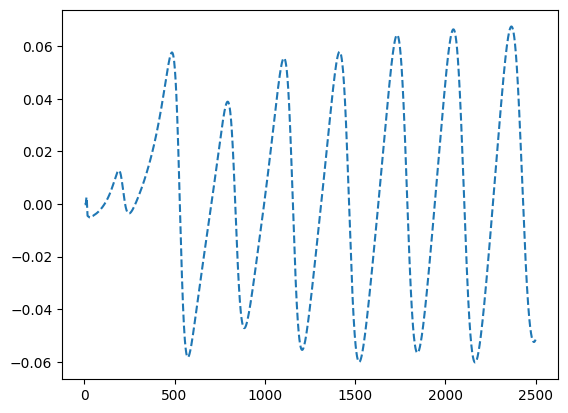

In [49]:
plt.plot(label[0], data[2]/LCDMdata[2]-1, "--")
plt.show()

## Template: Define your own species!